In [1]:
import torch
import numpy as np
from PIL import Image
import requests

In [2]:
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor

In [3]:
############检查环境路径

import os
import sys

# 获取当前工作目录
current_dir = os.getcwd()

# 构建 big_vision_repo 的路径
big_vision_path = os.path.join(current_dir, "big_vision_repo")

# 添加 big_vision_repo 到 PYTHONPATH
os.environ["PYTHONPATH"] = os.environ.get("PYTHONPATH", "") + os.pathsep + big_vision_path

# 确保 Python 知道 big_vision_repo 的位置
sys.path.append(big_vision_path)

# 验证 PYTHONPATH 是否设置成功
print(f"PYTHONPATH is set to: {os.environ['PYTHONPATH']}")


PYTHONPATH is set to: :/root/big_vision_repo


In [4]:
import os

# Step 1: Clone the big_vision repository
if not os.path.exists("big_vision_repo"):
    !git clone --quiet --branch=main --depth=1 https://github.com/google-research/big_vision big_vision_repo

# Step 2: Set the PYTHONPATH environment variable
os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + ':' + os.path.abspath("big_vision_repo")

# Verify the PYTHONPATH
print("PYTHONPATH is set to:", os.environ['PYTHONPATH'])#####配置环境路径

PYTHONPATH is set to: :/root/big_vision_repo:/root/big_vision_repo


In [5]:
######检查环境是否配置成功
try:
    import big_vision
    print("big_vision module imported successfully")
except ImportError as e:
    print(f"Error importing big_vision: {e}")

big_vision module imported successfully


In [6]:
####导入相关的数据包

import base64
import functools
import html
import io
import os
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import ml_collections

import tensorflow as tf
import sentencepiece

from IPython.display import display, HTML

import torch  # 确保导入 torch
from PIL import Image

# Import model definition from big_vision
from big_vision.models.proj.paligemma import paligemma
from big_vision.trainers.proj.paligemma import predict_fns

# Import big vision utilities
import big_vision.datasets.jsonl
import big_vision.utils
import big_vision.sharding

2024-09-03 22:38:04.272667: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [7]:
# 设置本地文件路径
#MODEL_PATH = "/root/autodl-tmp/model-out-8/fine-tuned-paligemma-3b-pt-224.f16.npz"
#MODEL_PATH = "/root/autodl-tmp/model-out-9mutial/latest_model_weights.npz"#####自己微调权重
MODEL_PATH = "/root/model/paligemma-3b-pt-224.f16.npz" ######官方权重
TOKENIZER_PATH = "/root/model/paligemma_tokenizer.model"
dataset_location = "/root/model/p-1.v1i.paligemma-multimodal/dataset"
#dataset_location = "E://ybx_GPR_test_paligemma//GPR.v3-b-scans-without-noise.paligemma"
# 加载模型示例
######定义一个函数用来加载模型，这个模型的路径是在D盘中或者云盘可以后续更改，使用NUmP加载模型。
def load_model(model_path):
    print(f"Loading model from {model_path}...")
    model = np.load(model_path)  # 使用 NumPy 加载模型
    return model

# 加载标记器示例######加载模型的标记器这个标记器就是用来处理paligemma的文本数据，将这个文本转换为模型可以理解的数字来表示，这样模型就能够读取文字。
def load_tokenizer(tokenizer_path):######################在加载模型的时候一定要注意模型：其实也可以直接加载，但是对于tokenizer需要转置为二进制再去读取模型的参数，
    print(f"Loading tokenizer from {tokenizer_path}...")#######（接上一行注释）这是因为tokenizer中包含着处理文本和映射的，规则这些数据通常需要存储为序列化对象，这些序列格式需要被反序列化才能python使用
    with open(tokenizer_path, 'rb') as f:####以二进制的形式打开文件
        tokenizer = f.read()  # 根据标记器的实际格式调整
    return tokenizer

# 加载模型和标记器
model = load_model(MODEL_PATH)######加载模型，调用刚才的模型加载函数
tokenizer = load_tokenizer(TOKENIZER_PATH)#####加载标记器，调用刚才定义的tokenizer加载函数
print("Model and tokenizer loaded successfully.")#输出模型和标记器加载成功

# 不要限制TF使用GPU或TPU
# tf.config.set_visible_devices([], "GPU")
# tf.config.set_visible_devices([], "TPU")

# 检查是否有GPU可用
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # 设置GPU使用限制为按需增长，而不是预先分配所有的显存
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

backend = jax.lib.xla_bridge.get_backend()
print(f"JAX version:  {jax.__version__}")
print(f"JAX platform: {backend.platform}")
print(f"JAX devices:  {jax.device_count()}")#####输出当前JAX的版本。

# 如果你希望JAX使用GPU，确保CUDA和cuDNN已正确安装并配置
if backend.platform == 'gpu':
    print("JAX is using GPU")
else:
    print("JAX is not using GPU, check your CUDA/cuDNN installation.")#####验证JAX是否可以正确调用GPU如果不能使用GPU 的话就直接使用CPU.


Loading model from /root/model/paligemma-3b-pt-224.f16.npz...
Loading tokenizer from /root/model/paligemma_tokenizer.model...
Model and tokenizer loaded successfully.
JAX version:  0.4.29
JAX platform: gpu
JAX devices:  1
JAX is using GPU


In [8]:
# @title Construct model and load params into RAM.

# Define model###设置一个不可改变的字典变量,,,,llm表是paligemma中的文本模型是lam
model_config = ml_collections.FrozenConfigDict({
    "llm": {"vocab_size": 257_152},
    "img": {"variant": "So400m/14", "pool_type": "none", "scan": True, "dtype_mm": "float16"}
})
model = paligemma.Model(**model_config)
tokenizer = sentencepiece.SentencePieceProcessor(TOKENIZER_PATH)

# Load params - this can take up to 1 minute in T4 colabs.
params = paligemma.load(None, MODEL_PATH, model_config)

# Define `decode` function to sample outputs from the model.
decode_fn = predict_fns.get_all(model)['decode']
decode = functools.partial(decode_fn, devices=jax.devices(), eos_token=tokenizer.eos_id())

In [9]:
# @title Move params to GPU/TPU memory.
#
# To keep HBM usage low and fit in a T4 GPU (16GB HBM) we opt to only finetune
# a part of the parameters. Additionally we keep the frozen params in float16
# and cast trainable to float32.

# Create a pytree mask of the trainable params.
def is_trainable_param(name, param):  # pylint: disable=unused-argument
  if name.startswith("llm/layers/attn/"):  return True
  if name.startswith("llm/"):              return False
  if name.startswith("img/"):              return False
  raise ValueError(f"Unexpected param name {name}")
trainable_mask = big_vision.utils.tree_map_with_names(is_trainable_param, params)

#
# If more than one device is available (e.g. multiple GPUs) the parameters can
# be sharded across them to reduce HBM usage per device.
mesh = jax.sharding.Mesh(jax.devices(), ("data"))

data_sharding = jax.sharding.NamedSharding(
    mesh, jax.sharding.PartitionSpec("data"))

params_sharding = big_vision.sharding.infer_sharding(
    params, strategy=[('.*', 'fsdp(axis="data")')], mesh=mesh)

# Yes: Some donated buffers are not usable.
warnings.filterwarnings(
    "ignore", message="Some donated buffers were not usable")

@functools.partial(jax.jit, donate_argnums=(0,), static_argnums=(1,))
def maybe_cast_to_f32(params, trainable):
  return jax.tree.map(lambda p, m: p.astype(jnp.float32) if m else p,
                      params, trainable)

# Loading all params in simultaneous - albeit much faster and more succinct -
# requires more RAM than the T4 colab runtimes have by default (12GB RAM).
# Instead we do it param by param.
params, treedef = jax.tree.flatten(params)
sharding_leaves = jax.tree.leaves(params_sharding)
trainable_leaves = jax.tree.leaves(trainable_mask)
######就是判断参数是否需要训练,如果需要训练的话就把转为需要训练的float32字符类型,然后再把训练完的参数转为模型最初的形式。
for idx, (sharding, trainable) in enumerate(zip(sharding_leaves, trainable_leaves)):
  params[idx] = big_vision.utils.reshard(params[idx], sharding)
  params[idx] = maybe_cast_to_f32(params[idx], trainable)
  params[idx].block_until_ready()
params = jax.tree.unflatten(treedef, params)#######将训练后的参数还原到模型参数中保持与原来模型参数一致。

# Print params to show what the model is made of.
def parameter_overview(params):
  for path, arr in big_vision.utils.tree_flatten_with_names(params)[0]:
    print(f"{path:80s} {str(arr.shape):22s} {arr.dtype}")###一个是80个字符，一个是22个字符

print(" == Model params == ")
parameter_overview(params)######遍历打印参数信息。

2024-09-03 22:38:20.062331: W external/xla/xla/service/gpu/nvptx_compiler.cc:763] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.5.40). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


 == Model params == 
img/Transformer/encoder_norm/bias                                                (1152,)                float16
img/Transformer/encoder_norm/scale                                               (1152,)                float16
img/Transformer/encoderblock/LayerNorm_0/bias                                    (27, 1152)             float16
img/Transformer/encoderblock/LayerNorm_0/scale                                   (27, 1152)             float16
img/Transformer/encoderblock/LayerNorm_1/bias                                    (27, 1152)             float16
img/Transformer/encoderblock/LayerNorm_1/scale                                   (27, 1152)             float16
img/Transformer/encoderblock/MlpBlock_0/Dense_0/bias                             (27, 4304)             float16
img/Transformer/encoderblock/MlpBlock_0/Dense_0/kernel                           (27, 1152, 4304)       float16
img/Transformer/encoderblock/MlpBlock_0/Dense_1/bias                             (2

In [10]:
# @title Define preprocess functions to create inputs to the model.

def preprocess_image(image, size=224):
  # Model has been trained to handle images of different aspects ratios
  # resized to 224x224 in the range [-1, 1]. Bilinear and antialias resize
  # options are helpful to improve quality in some tasks.
  image = np.asarray(image)
  if image.ndim == 2:  # Convert image without last channel into greyscale.
    image = np.stack((image,)*3, axis=-1)
  image = image[..., :3]  # Remove alpha layer.
  assert image.shape[-1] == 3

  image = tf.constant(image)
  image = tf.image.resize(image, (size, size), method='bilinear', antialias=True)
  return image.numpy() / 127.5 - 1.0  # [0, 255]->[-1,1]

def preprocess_tokens(prefix, suffix=None, seqlen=None):
  # Model has been trained to handle tokenized text composed of a prefix with
  # full attention and a suffix with causal attention.
  separator = "\n"
  tokens = tokenizer.encode(prefix, add_bos=True) + tokenizer.encode(separator)
  mask_ar = [0] * len(tokens)    # 0 to use full attention for prefix.
  mask_loss = [0] * len(tokens)  # 0 to not use prefix tokens in the loss.

  if suffix:
    suffix = tokenizer.encode(suffix, add_eos=True)
    tokens += suffix
    mask_ar += [1] * len(suffix)    # 1 to use causal attention for suffix.
    mask_loss += [1] * len(suffix)  # 1 to use suffix tokens in the loss.

  mask_input = [1] * len(tokens)    # 1 if its a token, 0 if padding.
  if seqlen:
    padding = [0] * max(0, seqlen - len(tokens))
    tokens = tokens[:seqlen] + padding
    mask_ar = mask_ar[:seqlen] + padding
    mask_loss = mask_loss[:seqlen] + padding
    mask_input = mask_input[:seqlen] + padding

  return jax.tree.map(np.array, (tokens, mask_ar, mask_loss, mask_input))

def postprocess_tokens(tokens):
  tokens = tokens.tolist()  # np.array to list[int]
  try:  # Remove tokens at and after EOS if any.
    eos_pos = tokens.index(tokenizer.eos_id())
    tokens = tokens[:eos_pos]
  except ValueError:
    pass
  return tokenizer.decode(tokens)


In [11]:
# @title Function to iterate over train and validation examples.
SEQLEN = 128
dataset_location = "/root/model/p-1.v1i.paligemma-multimodal/dataset"
# TODO: Consider data iterators skipping big_vision and tf.data?
train_dataset = big_vision.datasets.jsonl.DataSource(
    os.path.join(dataset_location, "_annotations.train2.jsonl"),
    fopen_keys={"image": dataset_location})

val_dataset = big_vision.datasets.jsonl.DataSource(
    os.path.join(dataset_location, "_annotations.valid2.jsonl"),
    fopen_keys={"image": dataset_location})


def train_data_iterator():
  """Never ending iterator over training examples."""
  # Shuffle examples and repeat so one can train for many epochs.
  dataset = train_dataset.get_tfdata().shuffle(1_000).repeat()
  for example in dataset.as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = "caption en"  # Could also be a different prefix per example.
    suffix = example["suffix"].decode().lower()
    tokens, mask_ar, mask_loss, _ = preprocess_tokens(prefix, suffix, SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "mask_ar": np.asarray(mask_ar),
        "mask_loss": np.asarray(mask_loss),
    }


def validation_data_iterator():
  """Single iterator over validation examples."""
  for example in val_dataset.get_tfdata(ordered=True).as_numpy_iterator():
    image = Image.open(io.BytesIO(example["image"]))
    image = preprocess_image(image)

    prefix = "caption en"  # Could also be a different prefix per example.
    tokens, mask_ar, _, mask_input = preprocess_tokens(prefix, seqlen=SEQLEN)

    yield {
        "image": np.asarray(image),
        "text": np.asarray(tokens),
        "mask_ar": np.asarray(mask_ar),
        "mask_input": np.asarray(mask_input),
    }


Training examples



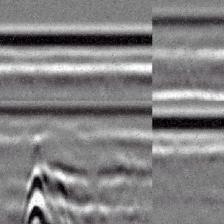
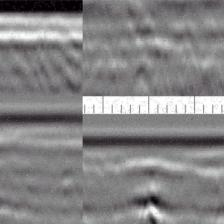
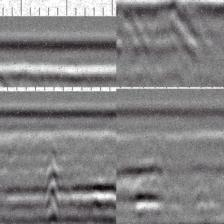
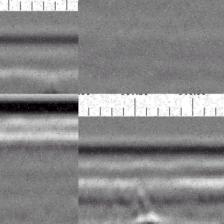
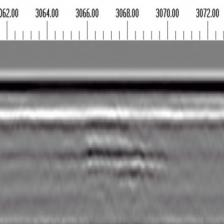
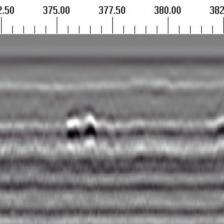
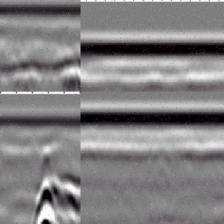
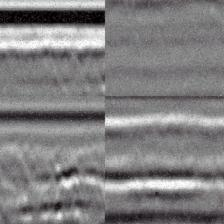

In [12]:
# @title Inspect training examples.
def render_inline(image, resize=(128, 128)):
  """Convert image into inline html."""
  image = Image.fromarray(image)
  image.resize(resize)
  with io.BytesIO() as buffer:
    image.save(buffer, format='jpeg')
    image_b64 = str(base64.b64encode(buffer.getvalue()), "utf-8")
    return f"data:image/jpeg;base64,{image_b64}"

def render_example(image, caption):
  image = ((image + 1)/2 * 255).astype(np.uint8)  # [-1,1] -> [0, 255]
  return f"""
    <div style="display: inline-flex; align-items: center; justify-content: center;">
        <img style="width:128px; height:128px;" src="{render_inline(image, resize=(64,64))}" />
        <p style="width:256px; margin:10px; font-size:small;">{html.escape(caption)}</p>
    </div>
    """

html_out = ""
for idx, example in zip(range(8), train_data_iterator()):
  caption = postprocess_tokens(example["text"])  # detokenize model input.
  caption = caption[len("caption en\n"):]        # strip prefix
  html_out += render_example(example["image"], caption)

print("Training examples")
display(HTML(html_out))

In [13]:
# @title Define the training step and evaluation loop.
#
# The main update_fn using simple SGD.
#
@functools.partial(jax.jit, donate_argnums=(0,))
def update_fn(params, batch, learning_rate):
  imgs, txts, mask_ar = batch["image"], batch["text"], batch["mask_ar"]

  def loss_fn(params):
    text_logits, _ = model.apply({"params": params}, imgs, txts[:, :-1], mask_ar[:, :-1], train=True)
    logp = jax.nn.log_softmax(text_logits, axis=-1)

    # The model takes as input txts[:, :-1] but the loss is defined as predicting
    # next tokens txts[:, 1:]. Additionally, mask_loss[:, 1:] indicates which tokens
    # are part of the loss (e.g. prefix and padded tokens are not included).
    mask_loss = batch["mask_loss"][:, 1:]
    targets = jax.nn.one_hot(txts[:, 1:], text_logits.shape[-1])

    # Compute the loss per example. i.e. the mean of per token pplx.
    # Since each example has a different number of tokens we normalize it.
    token_pplx = jnp.sum(logp * targets, axis=-1)  # sum across vocab_size.
    example_loss = -jnp.sum(token_pplx * mask_loss, axis=-1)  # sum across seq_len.
    example_loss /= jnp.clip(jnp.sum(mask_loss, -1), 1)  # weight by num of tokens.

    # batch_loss: mean of per example loss.
    return jnp.mean(example_loss)

  loss, grads = jax.value_and_grad(loss_fn)(params)

  # Apply gradients to trainable params using SGD.
  def apply_grad(param, gradient, trainable):
    if not trainable: return param
    return param - learning_rate * gradient

  params = jax.tree_util.tree_map(apply_grad, params, grads, trainable_mask)

  return params, loss

# Evaluation/inference loop.
def make_predictions(data_iterator, *, num_examples=None,
                     batch_size=4, seqlen=SEQLEN, sampler="greedy"):
  outputs = []
  while True:
    # Construct a list of examples in the batch.
    examples = []
    try:
      for _ in range(batch_size):
        examples.append(next(data_iterator))
        examples[-1]["_mask"] = np.array(True)  # Indicates true example.
    except StopIteration:
      if len(examples) == 0:
        return outputs

    # Not enough examples to complete a batch. Pad by repeating last example.
    while len(examples) % batch_size:
      examples.append(dict(examples[-1]))
      examples[-1]["_mask"] = np.array(False)  # Indicates padding example.

    # Convert list of examples into a dict of np.arrays and load onto devices.
    batch = jax.tree.map(lambda *x: np.stack(x), *examples)
    batch = big_vision.utils.reshard(batch, data_sharding)

    # Make model predictions
    tokens = decode({"params": params}, batch=batch,
                    max_decode_len=seqlen, sampler=sampler)

    # Fetch model predictions to device and detokenize.
    tokens, mask = jax.device_get((tokens, batch["_mask"]))
    tokens = tokens[mask]  # remove padding examples.
    responses = [postprocess_tokens(t) for t in tokens]

    # Append to html output.
    for example, response in zip(examples, responses):
      outputs.append((example["image"], response))
      if num_examples and len(outputs) >= num_examples:
        return outputs

Epoch: 1/30 - step:  1/10   lr: 0.01000   loss: 4.0249
Model predictions at step 1



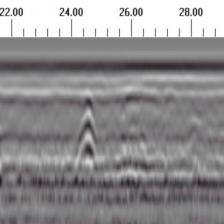
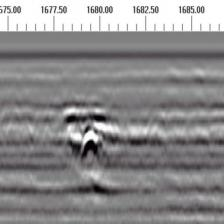
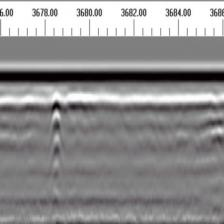
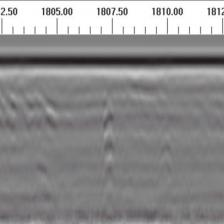

Epoch: 1/30 - step:  2/10   lr: 0.00976   loss: 3.0496
Model predictions at step 2



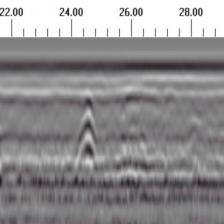
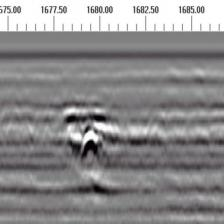
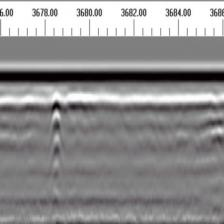
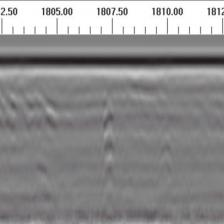

Epoch: 1/30 - step:  3/10   lr: 0.00905   loss: 2.5748
Epoch: 1/30 - step:  4/10   lr: 0.00794   loss: 1.9838
Model predictions at step 4



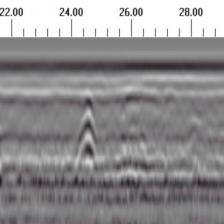
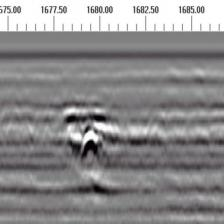
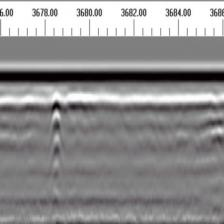
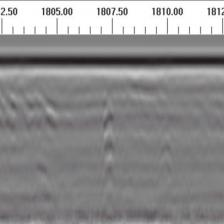

Epoch: 1/30 - step:  5/10   lr: 0.00655   loss: 1.7588
Epoch: 1/30 - step:  6/10   lr: 0.00500   loss: 1.7216
Model predictions at step 6



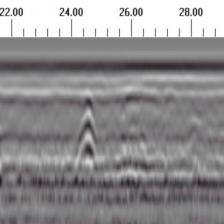
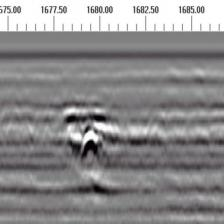
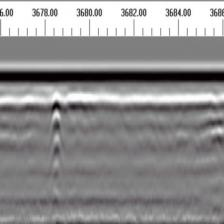
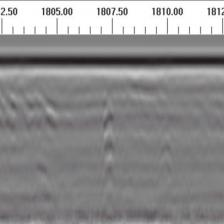

Epoch: 1/30 - step:  7/10   lr: 0.00345   loss: 1.4495
Epoch: 1/30 - step:  8/10   lr: 0.00206   loss: 1.3727
Model predictions at step 8



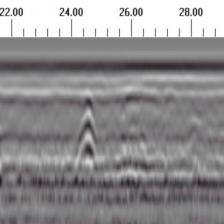
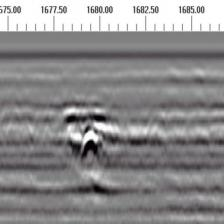
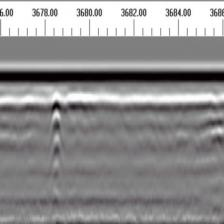
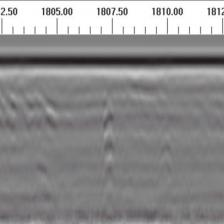

Epoch: 1/30 - step:  9/10   lr: 0.00095   loss: 1.3477
Epoch: 1/30 - step: 10/10   lr: 0.00024   loss: 1.0480
Model predictions at step 10



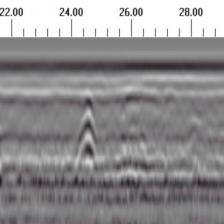
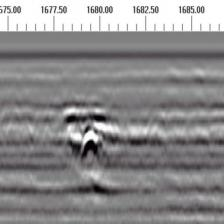
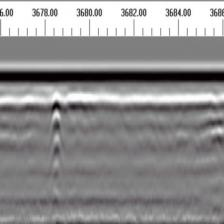
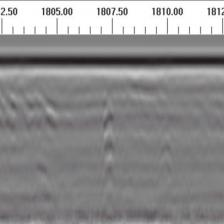

Epoch 1/30 completed in 104.93 seconds
Epoch progress: 1/30
Epoch: 2/30 - step:  1/10   lr: 0.01000   loss: 1.0586
Model predictions at step 1



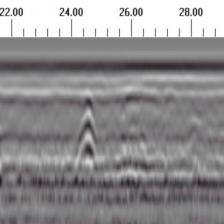
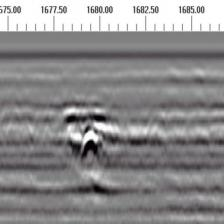
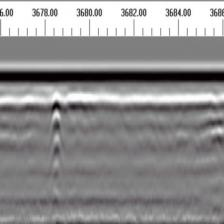
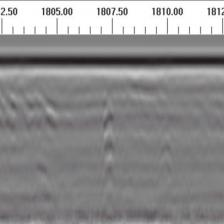

Epoch: 2/30 - step:  2/10   lr: 0.00976   loss: 1.2570
Model predictions at step 2



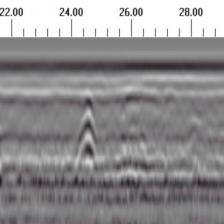
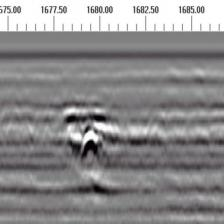
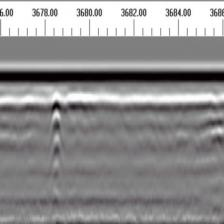
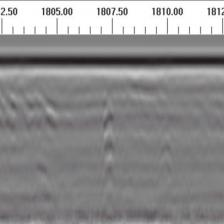

Epoch: 2/30 - step:  3/10   lr: 0.00905   loss: 2.1853
Epoch: 2/30 - step:  4/10   lr: 0.00794   loss: 1.1405
Model predictions at step 4



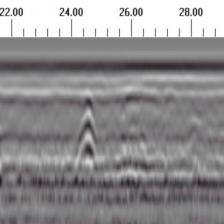
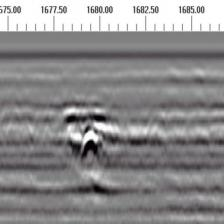
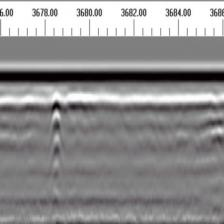
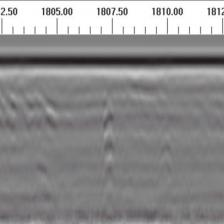

Epoch: 2/30 - step:  5/10   lr: 0.00655   loss: 0.8651
Epoch: 2/30 - step:  6/10   lr: 0.00500   loss: 1.0553
Model predictions at step 6



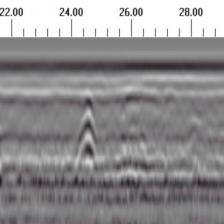
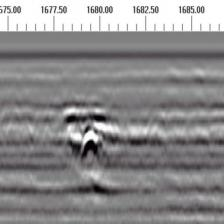
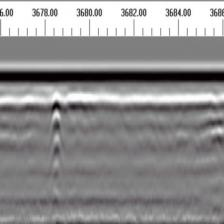
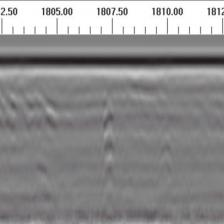

Epoch: 2/30 - step:  7/10   lr: 0.00345   loss: 0.7450
Epoch: 2/30 - step:  8/10   lr: 0.00206   loss: 0.6722
Model predictions at step 8



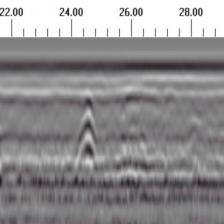
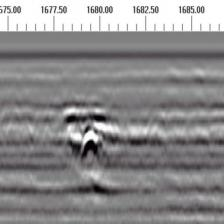
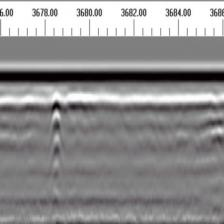
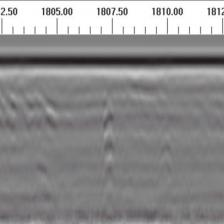

Epoch: 2/30 - step:  9/10   lr: 0.00095   loss: 0.8087
Epoch: 2/30 - step: 10/10   lr: 0.00024   loss: 0.6951
Model predictions at step 10



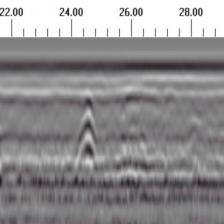
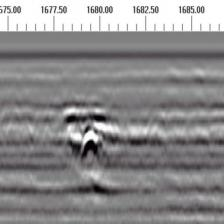
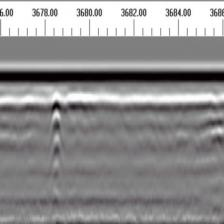
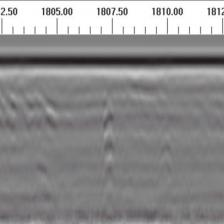

Epoch 2/30 completed in 20.20 seconds
Epoch progress: 2/30
Epoch: 3/30 - step:  1/10   lr: 0.01000   loss: 0.7687
Model predictions at step 1



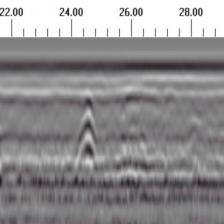
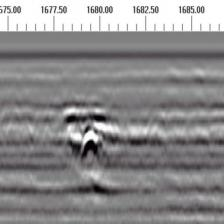
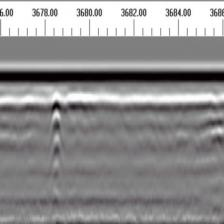
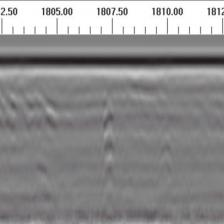

Epoch: 3/30 - step:  2/10   lr: 0.00976   loss: 0.5858
Model predictions at step 2



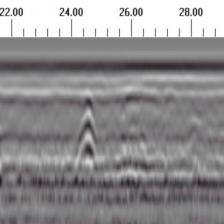
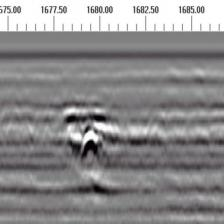
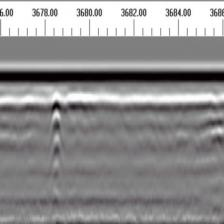
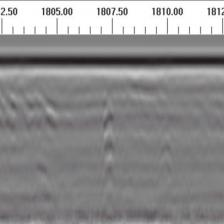

Epoch: 3/30 - step:  3/10   lr: 0.00905   loss: 0.6356
Epoch: 3/30 - step:  4/10   lr: 0.00794   loss: 0.4857
Model predictions at step 4



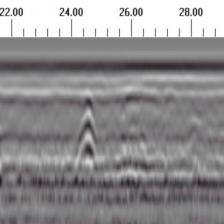
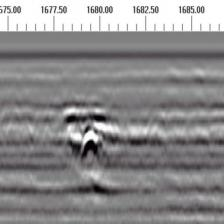
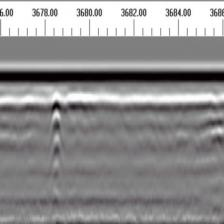
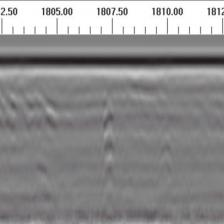

Epoch: 3/30 - step:  5/10   lr: 0.00655   loss: 0.6818
Epoch: 3/30 - step:  6/10   lr: 0.00500   loss: 0.4450
Model predictions at step 6



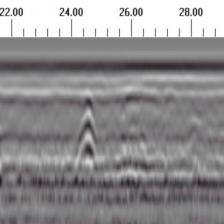
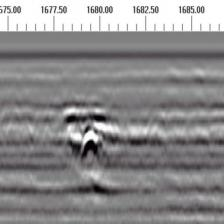
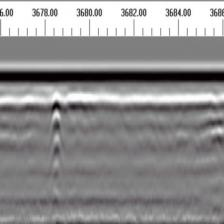
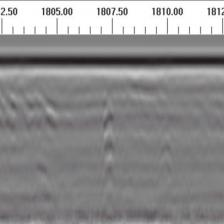

Epoch: 3/30 - step:  7/10   lr: 0.00345   loss: 0.5043
Epoch: 3/30 - step:  8/10   lr: 0.00206   loss: 0.3932
Model predictions at step 8



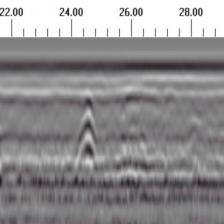
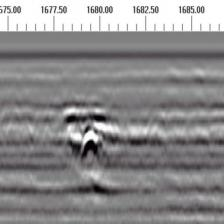
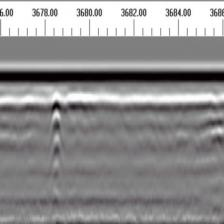
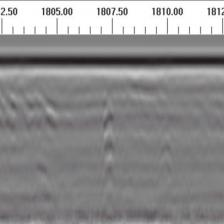

Epoch: 3/30 - step:  9/10   lr: 0.00095   loss: 0.4715
Epoch: 3/30 - step: 10/10   lr: 0.00024   loss: 0.5302
Model predictions at step 10



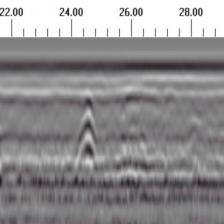
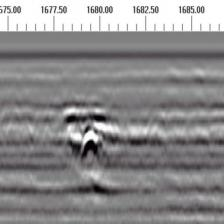
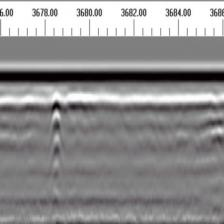
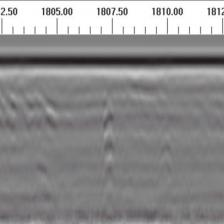

Epoch 3/30 completed in 20.37 seconds
Epoch progress: 3/30
Epoch: 4/30 - step:  1/10   lr: 0.01000   loss: 0.4476
Model predictions at step 1



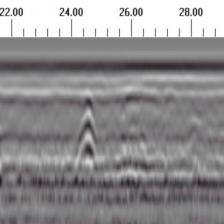
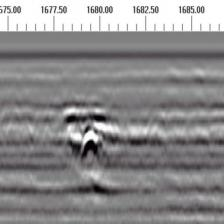
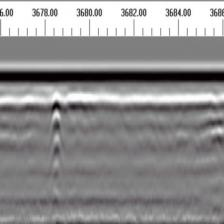
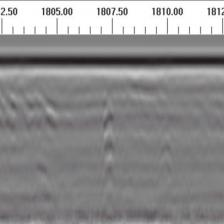

Epoch: 4/30 - step:  2/10   lr: 0.00976   loss: 0.3859
Model predictions at step 2



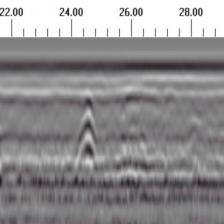
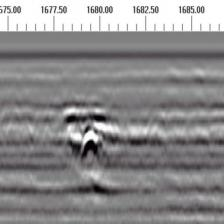
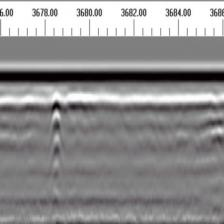
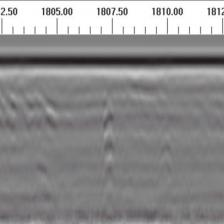

Epoch: 4/30 - step:  3/10   lr: 0.00905   loss: 0.3839
Epoch: 4/30 - step:  4/10   lr: 0.00794   loss: 0.5023
Model predictions at step 4



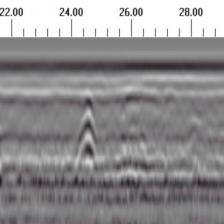
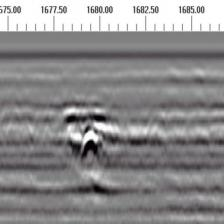
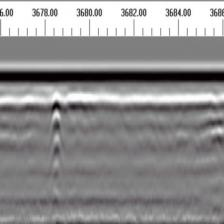
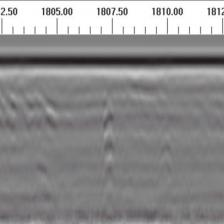

Epoch: 4/30 - step:  5/10   lr: 0.00655   loss: 0.4581
Epoch: 4/30 - step:  6/10   lr: 0.00500   loss: 0.4057
Model predictions at step 6



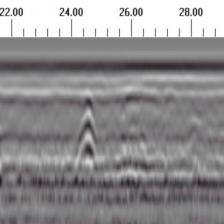
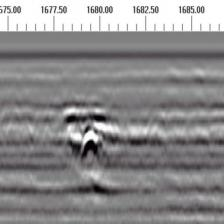
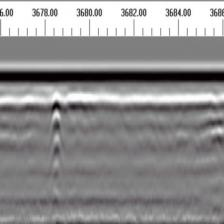
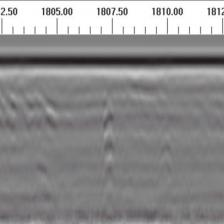

Epoch: 4/30 - step:  7/10   lr: 0.00345   loss: 0.3639
Epoch: 4/30 - step:  8/10   lr: 0.00206   loss: 0.4622
Model predictions at step 8



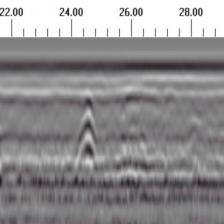
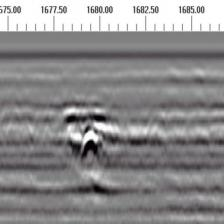
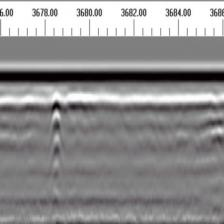
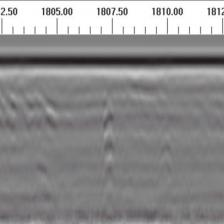

Epoch: 4/30 - step:  9/10   lr: 0.00095   loss: 0.5017
Epoch: 4/30 - step: 10/10   lr: 0.00024   loss: 0.3862
Model predictions at step 10



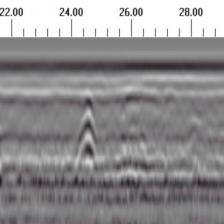
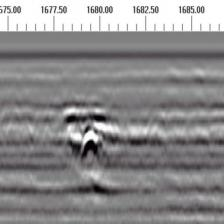
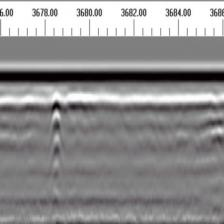
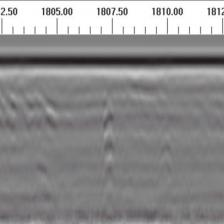

Epoch 4/30 completed in 20.32 seconds
Epoch progress: 4/30
Epoch: 5/30 - step:  1/10   lr: 0.01000   loss: 0.3458
Model predictions at step 1



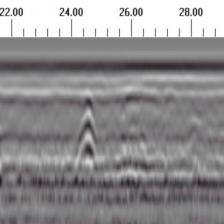
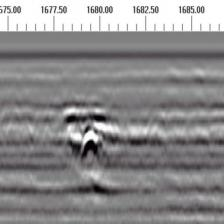
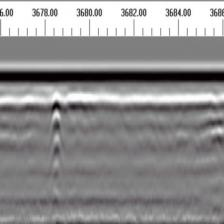
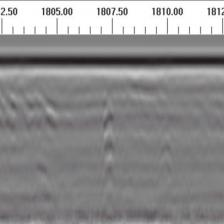

Epoch: 5/30 - step:  2/10   lr: 0.00976   loss: 0.3119
Model predictions at step 2



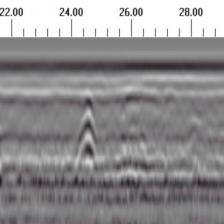
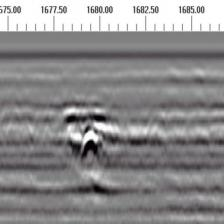
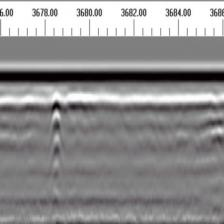
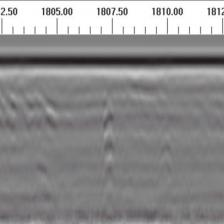

Epoch: 5/30 - step:  3/10   lr: 0.00905   loss: 0.4831
Epoch: 5/30 - step:  4/10   lr: 0.00794   loss: 0.4137
Model predictions at step 4



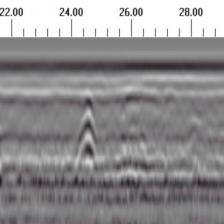
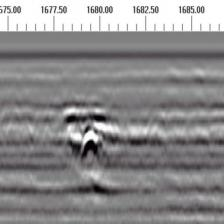
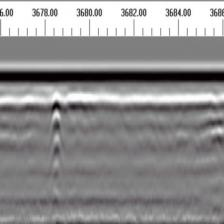
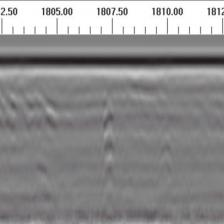

Epoch: 5/30 - step:  5/10   lr: 0.00655   loss: 0.2880
Epoch: 5/30 - step:  6/10   lr: 0.00500   loss: 0.3177
Model predictions at step 6



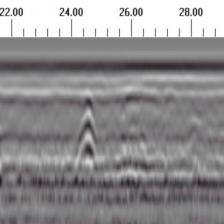
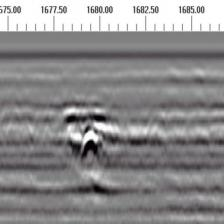
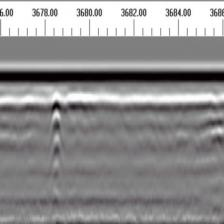
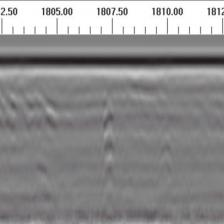

Epoch: 5/30 - step:  7/10   lr: 0.00345   loss: 0.4557
Epoch: 5/30 - step:  8/10   lr: 0.00206   loss: 0.3448
Model predictions at step 8



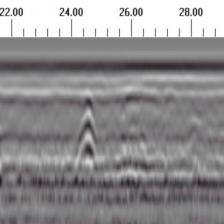
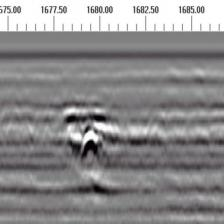
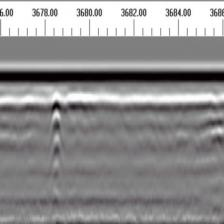
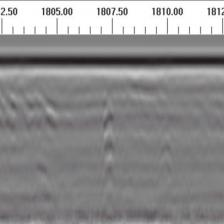

Epoch: 5/30 - step:  9/10   lr: 0.00095   loss: 0.3149
Epoch: 5/30 - step: 10/10   lr: 0.00024   loss: 0.3373
Model predictions at step 10



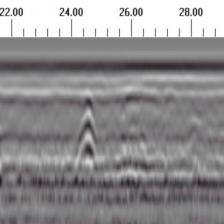
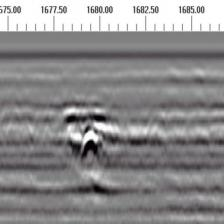
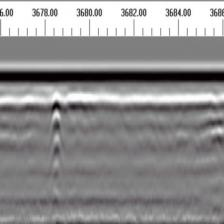
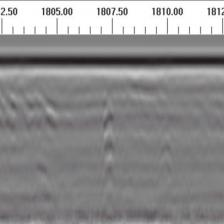

Epoch 5/30 completed in 20.23 seconds
Epoch progress: 5/30
Epoch: 6/30 - step:  1/10   lr: 0.01000   loss: 0.3694
Model predictions at step 1



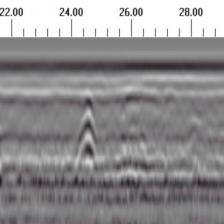
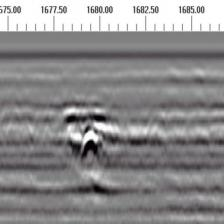
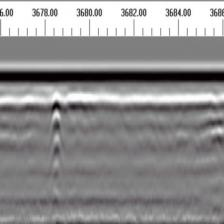
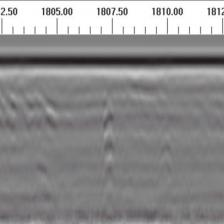

Epoch: 6/30 - step:  2/10   lr: 0.00976   loss: 0.4203
Model predictions at step 2



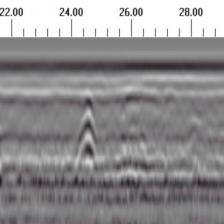
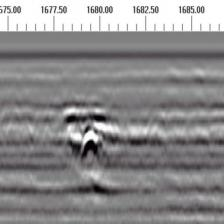
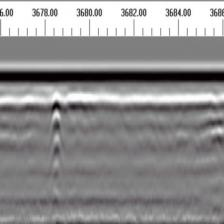
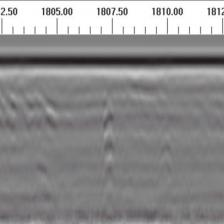

Epoch: 6/30 - step:  3/10   lr: 0.00905   loss: 0.4897
Epoch: 6/30 - step:  4/10   lr: 0.00794   loss: 0.3339
Model predictions at step 4



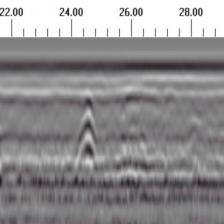
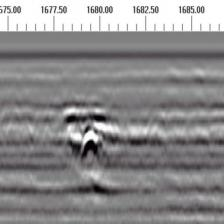
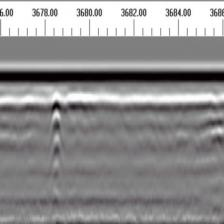
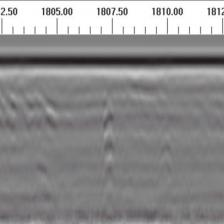

Epoch: 6/30 - step:  5/10   lr: 0.00655   loss: 0.3742
Epoch: 6/30 - step:  6/10   lr: 0.00500   loss: 0.3299
Model predictions at step 6



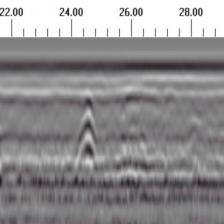
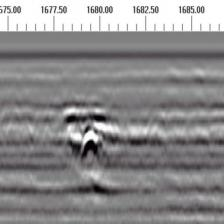
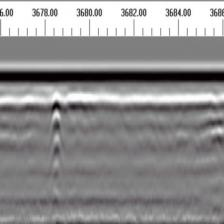
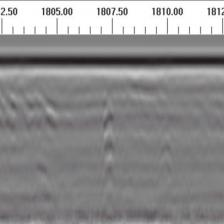

Epoch: 6/30 - step:  7/10   lr: 0.00345   loss: 0.2685
Epoch: 6/30 - step:  8/10   lr: 0.00206   loss: 0.3563
Model predictions at step 8



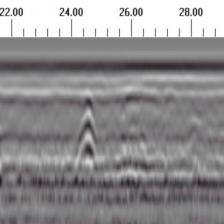
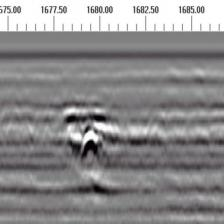
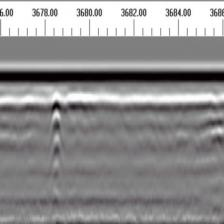
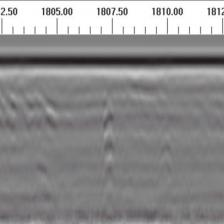

Epoch: 6/30 - step:  9/10   lr: 0.00095   loss: 0.4647
Epoch: 6/30 - step: 10/10   lr: 0.00024   loss: 0.2659
Model predictions at step 10



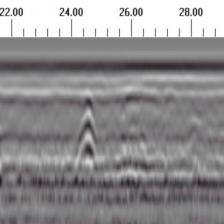
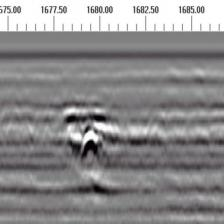
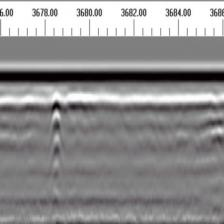
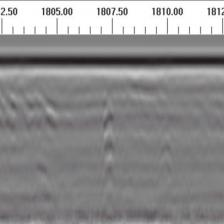

Epoch 6/30 completed in 20.34 seconds
Epoch progress: 6/30
Epoch: 7/30 - step:  1/10   lr: 0.01000   loss: 0.3005
Model predictions at step 1



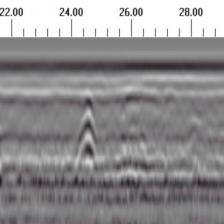
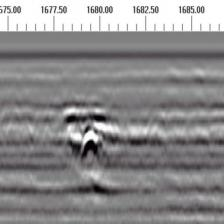
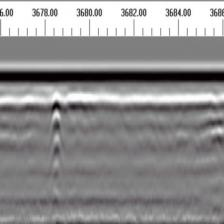
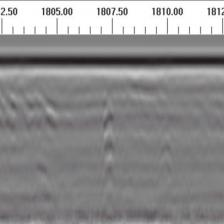

Epoch: 7/30 - step:  2/10   lr: 0.00976   loss: 0.2957
Model predictions at step 2



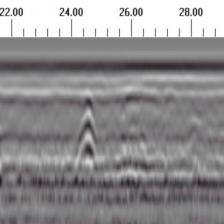
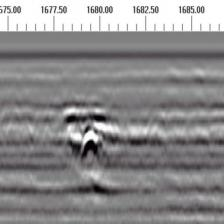
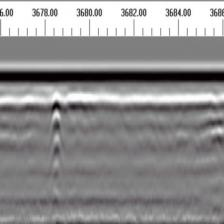
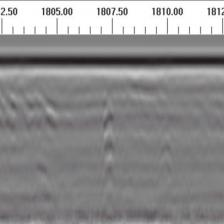

Epoch: 7/30 - step:  3/10   lr: 0.00905   loss: 0.3586
Epoch: 7/30 - step:  4/10   lr: 0.00794   loss: 0.3843
Model predictions at step 4



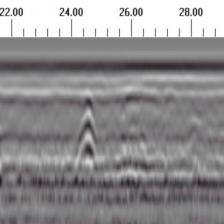
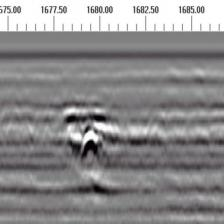
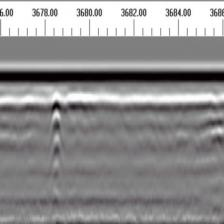
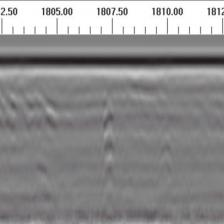

Epoch: 7/30 - step:  5/10   lr: 0.00655   loss: 0.2727
Epoch: 7/30 - step:  6/10   lr: 0.00500   loss: 0.3770
Model predictions at step 6



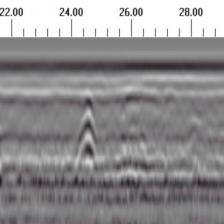
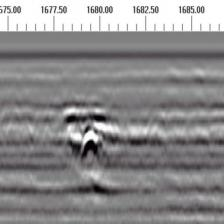
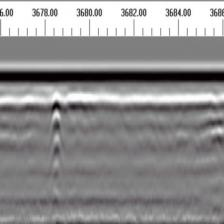
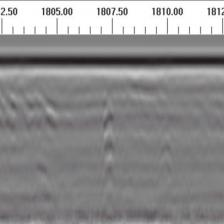

Epoch: 7/30 - step:  7/10   lr: 0.00345   loss: 0.2889
Epoch: 7/30 - step:  8/10   lr: 0.00206   loss: 0.2877
Model predictions at step 8



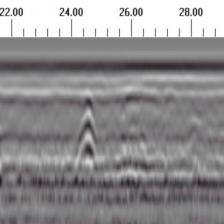
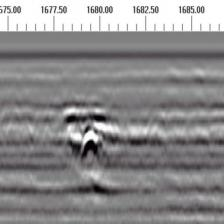
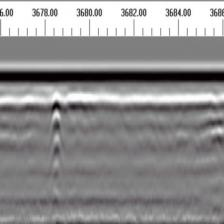
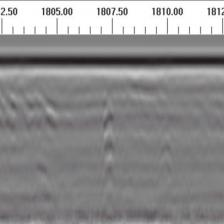

Epoch: 7/30 - step:  9/10   lr: 0.00095   loss: 0.3220
Epoch: 7/30 - step: 10/10   lr: 0.00024   loss: 0.3199
Model predictions at step 10



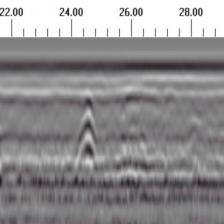
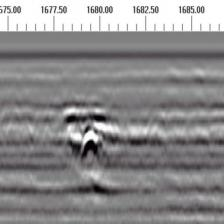
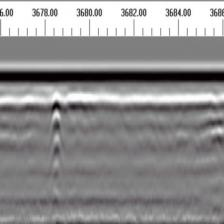
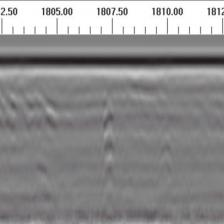

Epoch 7/30 completed in 20.22 seconds
Epoch progress: 7/30
Epoch: 8/30 - step:  1/10   lr: 0.01000   loss: 0.2425
Model predictions at step 1



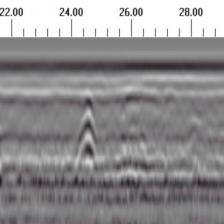
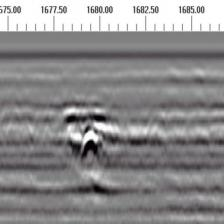
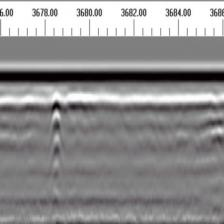
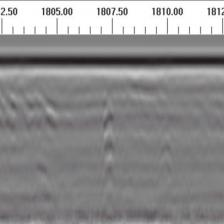

Epoch: 8/30 - step:  2/10   lr: 0.00976   loss: 0.2747
Model predictions at step 2



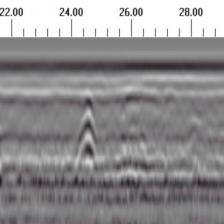
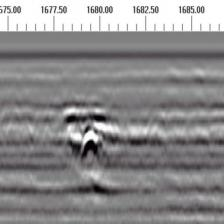
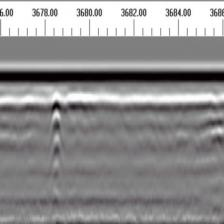
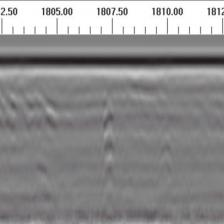

Epoch: 8/30 - step:  3/10   lr: 0.00905   loss: 0.4249
Epoch: 8/30 - step:  4/10   lr: 0.00794   loss: 0.3886
Model predictions at step 4



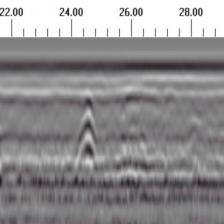
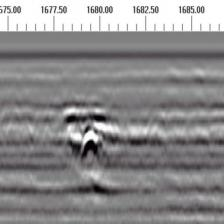
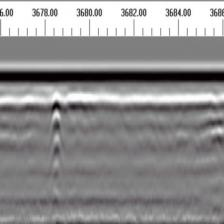
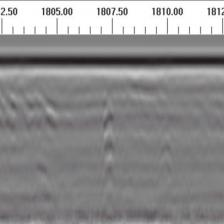

Epoch: 8/30 - step:  5/10   lr: 0.00655   loss: 0.2741
Epoch: 8/30 - step:  6/10   lr: 0.00500   loss: 0.2762
Model predictions at step 6



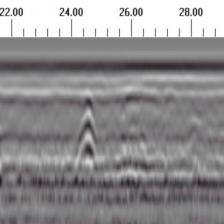
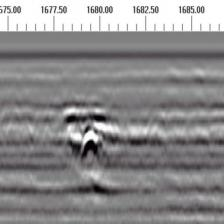
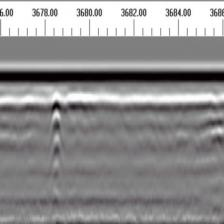
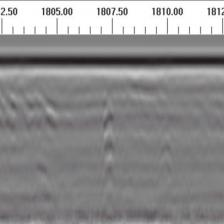

Epoch: 8/30 - step:  7/10   lr: 0.00345   loss: 0.2331
Epoch: 8/30 - step:  8/10   lr: 0.00206   loss: 0.3514
Model predictions at step 8



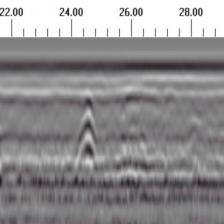
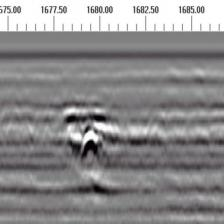
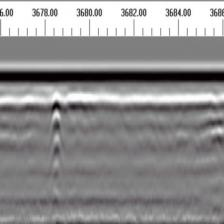
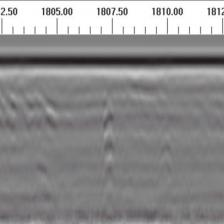

Epoch: 8/30 - step:  9/10   lr: 0.00095   loss: 0.2515
Epoch: 8/30 - step: 10/10   lr: 0.00024   loss: 0.3032
Model predictions at step 10



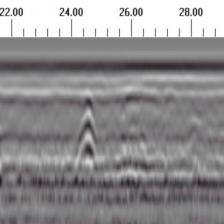
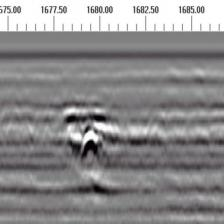
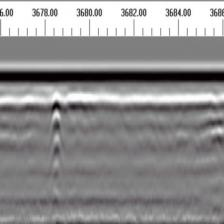
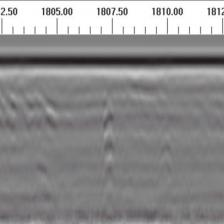

Epoch 8/30 completed in 20.34 seconds
Epoch progress: 8/30
Epoch: 9/30 - step:  1/10   lr: 0.01000   loss: 0.2514
Model predictions at step 1



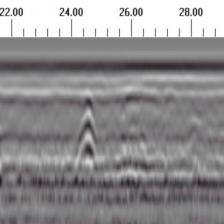
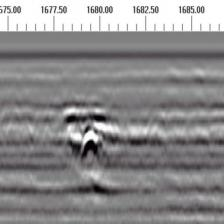
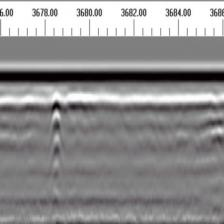
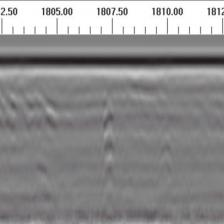

Epoch: 9/30 - step:  2/10   lr: 0.00976   loss: 0.2528
Model predictions at step 2



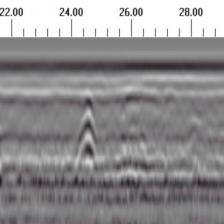
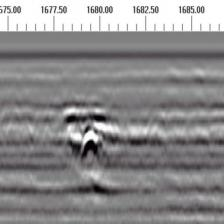
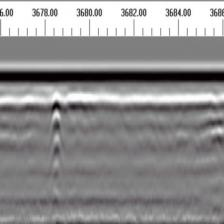
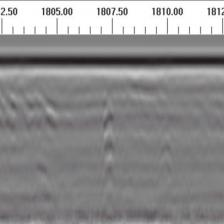

Epoch: 9/30 - step:  3/10   lr: 0.00905   loss: 0.2742
Epoch: 9/30 - step:  4/10   lr: 0.00794   loss: 0.4211
Model predictions at step 4



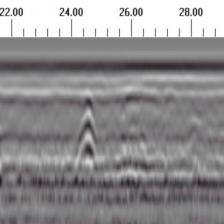
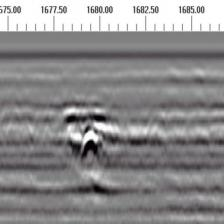
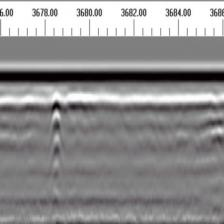
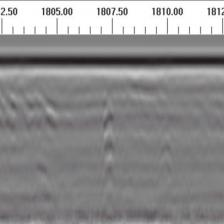

Epoch: 9/30 - step:  5/10   lr: 0.00655   loss: 0.3927
Epoch: 9/30 - step:  6/10   lr: 0.00500   loss: 0.2372
Model predictions at step 6



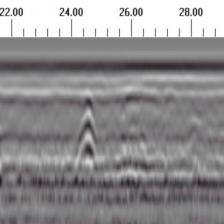
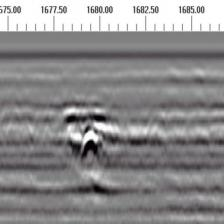
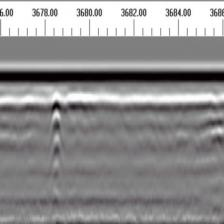
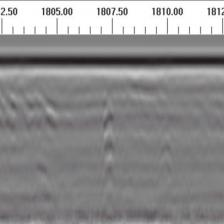

Epoch: 9/30 - step:  7/10   lr: 0.00345   loss: 0.2736
Epoch: 9/30 - step:  8/10   lr: 0.00206   loss: 0.3756
Model predictions at step 8



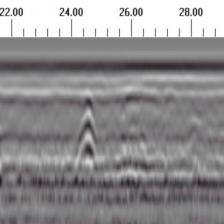
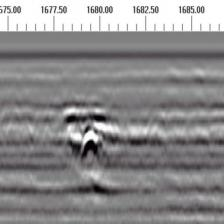
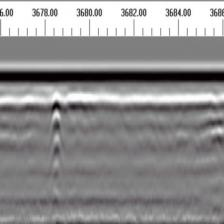
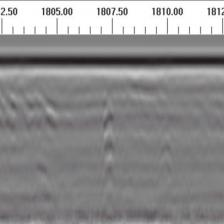

Epoch: 9/30 - step:  9/10   lr: 0.00095   loss: 0.2414
Epoch: 9/30 - step: 10/10   lr: 0.00024   loss: 0.3277
Model predictions at step 10



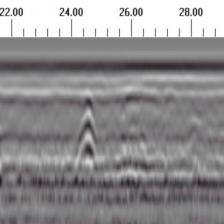
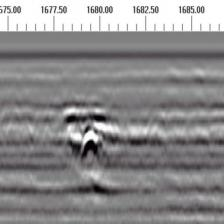
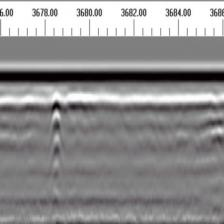
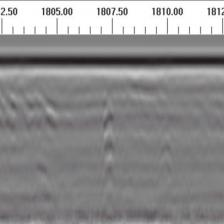

Epoch 9/30 completed in 20.22 seconds
Epoch progress: 9/30
Epoch: 10/30 - step:  1/10   lr: 0.01000   loss: 0.2286
Model predictions at step 1



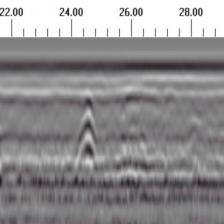
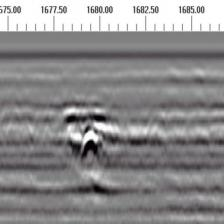
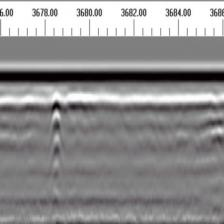
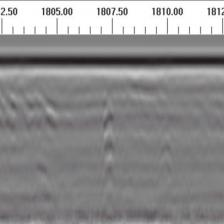

Epoch: 10/30 - step:  2/10   lr: 0.00976   loss: 0.3012
Model predictions at step 2



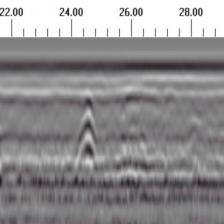
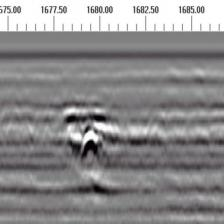
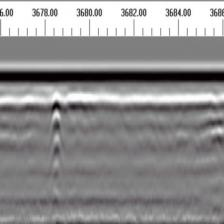
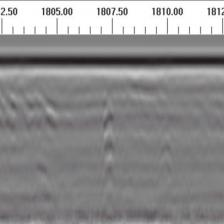

Epoch: 10/30 - step:  3/10   lr: 0.00905   loss: 0.2451
Epoch: 10/30 - step:  4/10   lr: 0.00794   loss: 0.3098
Model predictions at step 4



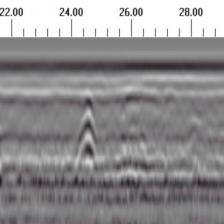
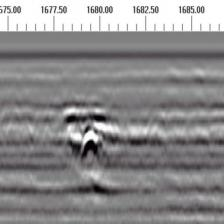
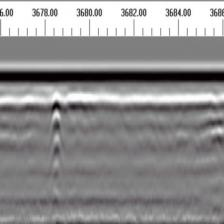
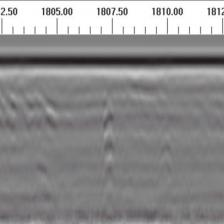

Epoch: 10/30 - step:  5/10   lr: 0.00655   loss: 0.2752
Epoch: 10/30 - step:  6/10   lr: 0.00500   loss: 0.2639
Model predictions at step 6



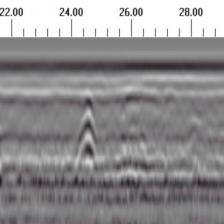
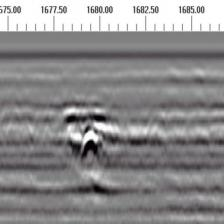
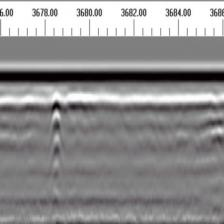
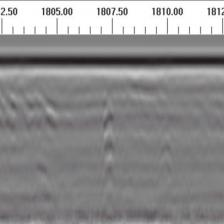

Epoch: 10/30 - step:  7/10   lr: 0.00345   loss: 0.4070
Epoch: 10/30 - step:  8/10   lr: 0.00206   loss: 0.2412
Model predictions at step 8



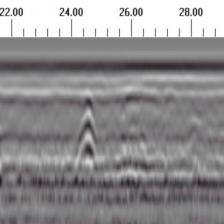
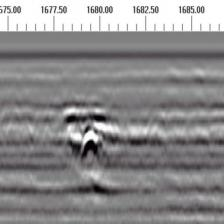
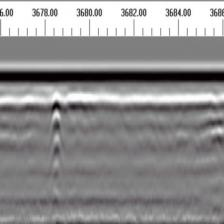
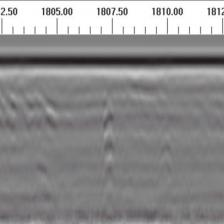

Epoch: 10/30 - step:  9/10   lr: 0.00095   loss: 0.1897
Epoch: 10/30 - step: 10/10   lr: 0.00024   loss: 0.2681
Model predictions at step 10



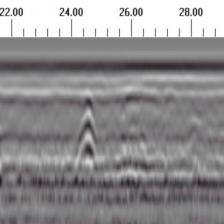
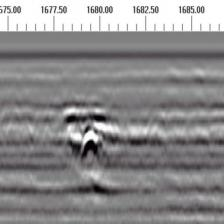
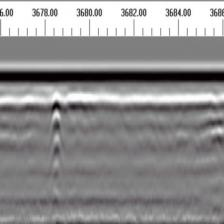
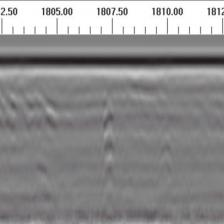

Epoch 10/30 completed in 20.23 seconds
Epoch progress: 10/30
Epoch: 11/30 - step:  1/10   lr: 0.01000   loss: 0.2318
Model predictions at step 1



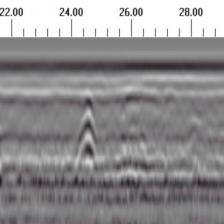
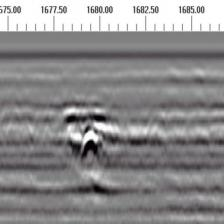
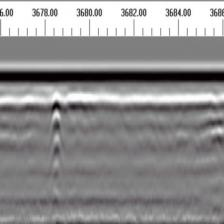
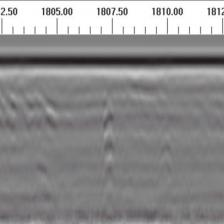

Epoch: 11/30 - step:  2/10   lr: 0.00976   loss: 0.2492
Model predictions at step 2



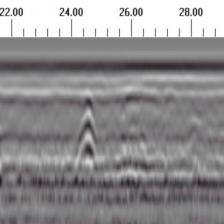
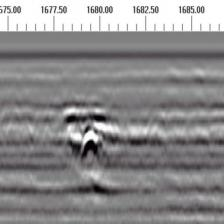
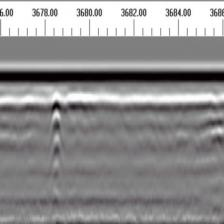
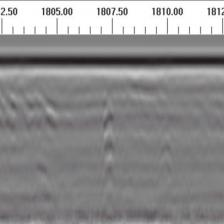

Epoch: 11/30 - step:  3/10   lr: 0.00905   loss: 0.3127
Epoch: 11/30 - step:  4/10   lr: 0.00794   loss: 0.2684
Model predictions at step 4



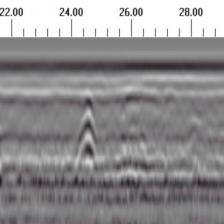
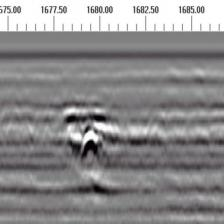
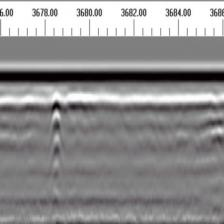
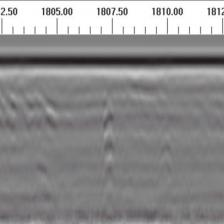

Epoch: 11/30 - step:  5/10   lr: 0.00655   loss: 0.2775
Epoch: 11/30 - step:  6/10   lr: 0.00500   loss: 0.2773
Model predictions at step 6



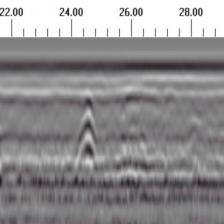
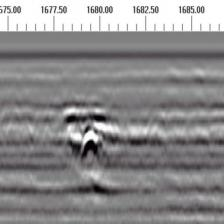
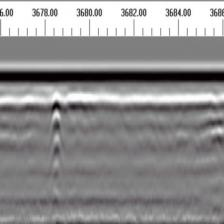
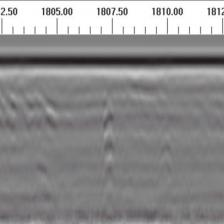

Epoch: 11/30 - step:  7/10   lr: 0.00345   loss: 0.2746
Epoch: 11/30 - step:  8/10   lr: 0.00206   loss: 0.2370
Model predictions at step 8



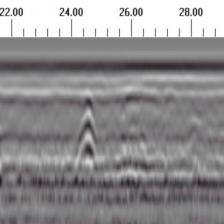
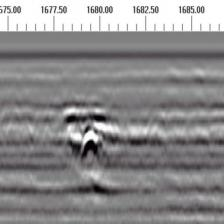
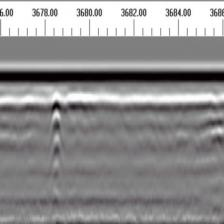
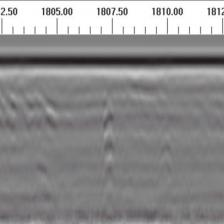

Epoch: 11/30 - step:  9/10   lr: 0.00095   loss: 0.2422
Epoch: 11/30 - step: 10/10   lr: 0.00024   loss: 0.2936
Model predictions at step 10



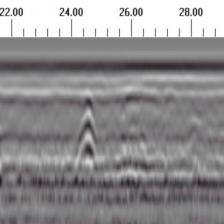
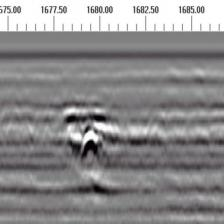
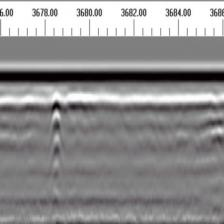
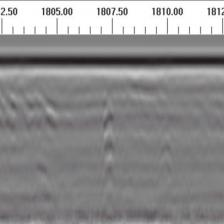

Epoch 11/30 completed in 20.23 seconds
Epoch progress: 11/30
Epoch: 12/30 - step:  1/10   lr: 0.01000   loss: 0.2436
Model predictions at step 1



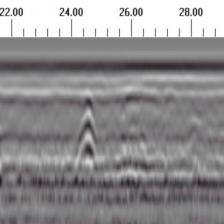
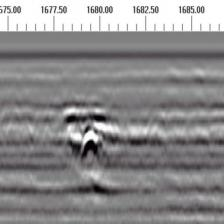
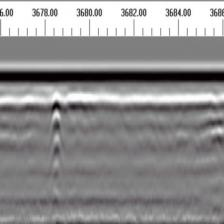
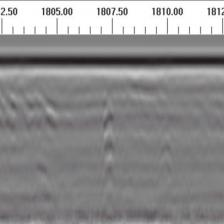

Epoch: 12/30 - step:  2/10   lr: 0.00976   loss: 0.2585
Model predictions at step 2



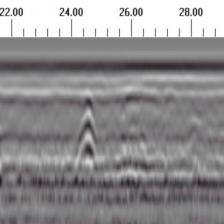
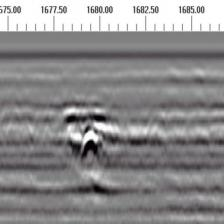
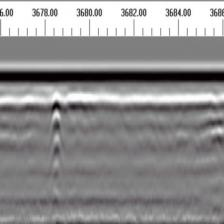
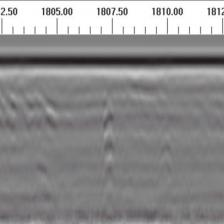

Epoch: 12/30 - step:  3/10   lr: 0.00905   loss: 0.2510
Epoch: 12/30 - step:  4/10   lr: 0.00794   loss: 0.2576
Model predictions at step 4



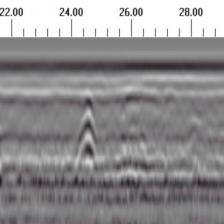
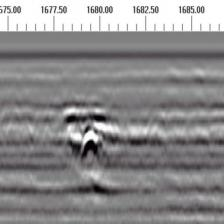
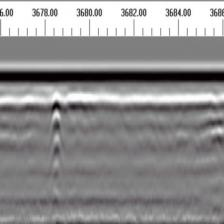
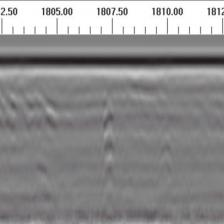

Epoch: 12/30 - step:  5/10   lr: 0.00655   loss: 0.2826
Epoch: 12/30 - step:  6/10   lr: 0.00500   loss: 0.2605
Model predictions at step 6



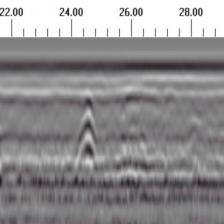
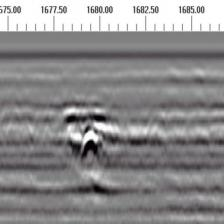
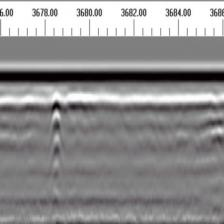
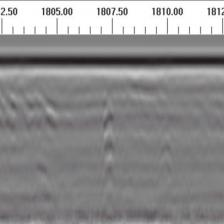

Epoch: 12/30 - step:  7/10   lr: 0.00345   loss: 0.2549
Epoch: 12/30 - step:  8/10   lr: 0.00206   loss: 0.3253
Model predictions at step 8



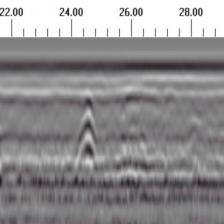
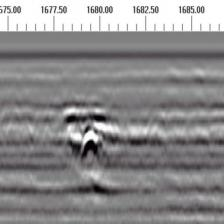
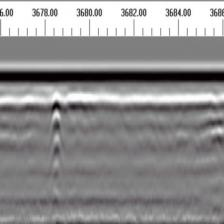
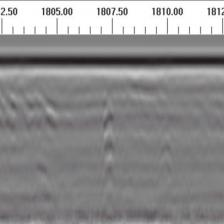

Epoch: 12/30 - step:  9/10   lr: 0.00095   loss: 0.2386
Epoch: 12/30 - step: 10/10   lr: 0.00024   loss: 0.2190
Model predictions at step 10



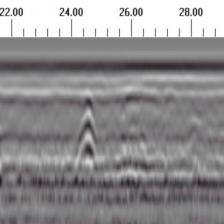
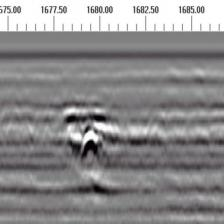
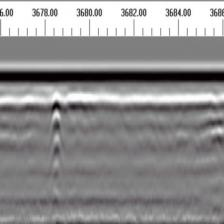
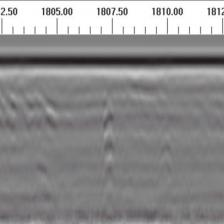

Epoch 12/30 completed in 20.21 seconds
Epoch progress: 12/30
Epoch: 13/30 - step:  1/10   lr: 0.01000   loss: 0.2494
Model predictions at step 1



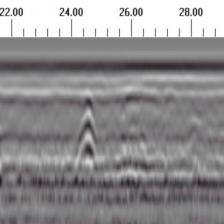
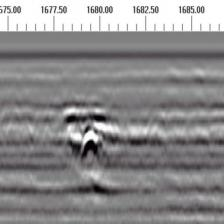
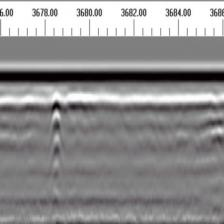
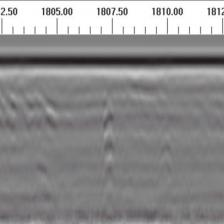

Epoch: 13/30 - step:  2/10   lr: 0.00976   loss: 0.2048
Model predictions at step 2



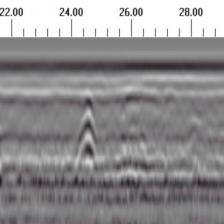
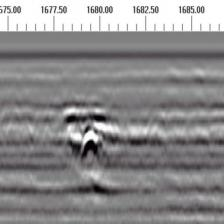
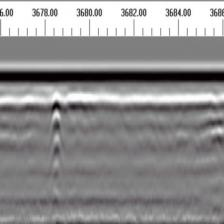
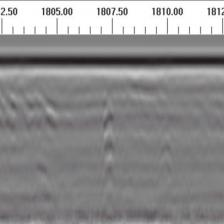

Epoch: 13/30 - step:  3/10   lr: 0.00905   loss: 0.2232
Epoch: 13/30 - step:  4/10   lr: 0.00794   loss: 0.2095
Model predictions at step 4



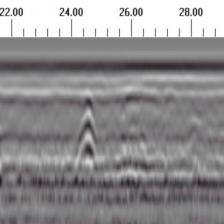
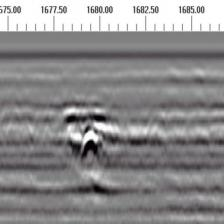
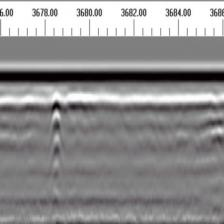
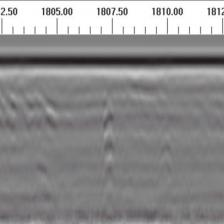

Epoch: 13/30 - step:  5/10   lr: 0.00655   loss: 0.2631
Epoch: 13/30 - step:  6/10   lr: 0.00500   loss: 0.1630
Model predictions at step 6



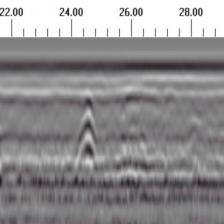
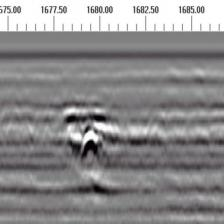
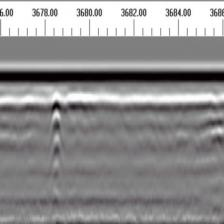
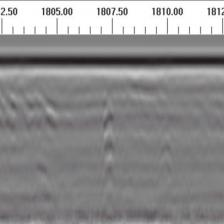

Epoch: 13/30 - step:  7/10   lr: 0.00345   loss: 0.2915
Epoch: 13/30 - step:  8/10   lr: 0.00206   loss: 0.2381
Model predictions at step 8



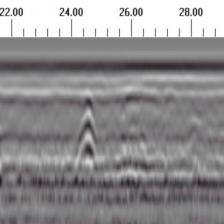
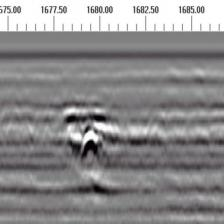
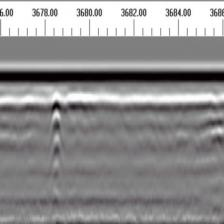
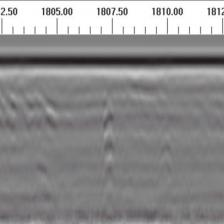

Epoch: 13/30 - step:  9/10   lr: 0.00095   loss: 0.1934
Epoch: 13/30 - step: 10/10   lr: 0.00024   loss: 0.2063
Model predictions at step 10



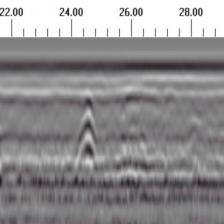
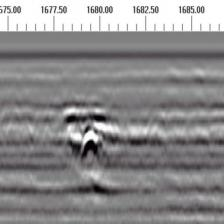
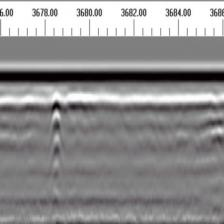
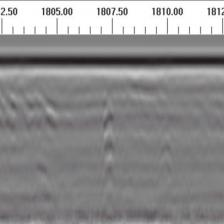

Epoch 13/30 completed in 20.33 seconds
Epoch progress: 13/30
Epoch: 14/30 - step:  1/10   lr: 0.01000   loss: 0.1970
Model predictions at step 1


In [ ]:
# @title Run training loop.
#
# Run a short training loop with cosine learning rate schedule.
#
# Note: the first step can be quite slow on some machines (up to several minutes)
# due to XLA compilation of the jax.jit'd function.
#


import time
from tqdm import tqdm

# Hyperparameters
BATCH_SIZE = 16
TRAIN_EXAMPLES = 170
LEARNING_RATE = 0.01
EPOCHS = 30  # 手动设置的总epoch数

TRAIN_STEPS = TRAIN_EXAMPLES // BATCH_SIZE
EVAL_STEPS = TRAIN_STEPS // 4

train_data_it = train_data_iterator()

sched_fn = big_vision.utils.create_learning_rate_schedule(
    total_steps=TRAIN_STEPS+1, base=LEARNING_RATE,
    decay_type="cosine", warmup_percent=0.10)

for epoch in range(1, EPOCHS+1):
    start_time = time.time()
    
    for step in range(1, TRAIN_STEPS+1):
        # Make list of N training examples.
        examples = [next(train_data_it) for _ in range(BATCH_SIZE)]

        # Convert list of examples into a dict of np.arrays and load onto devices.
        batch = jax.tree.map(lambda *x: np.stack(x), *examples)
        batch = big_vision.utils.reshard(batch, data_sharding)

        # Training step and report training loss
        learning_rate = sched_fn(step)
        params, loss = update_fn(params, batch, learning_rate)

        loss = jax.device_get(loss)
        print(f"Epoch: {epoch}/{EPOCHS} - step: {step:2d}/{TRAIN_STEPS:2d}   lr: {learning_rate:.5f}   loss: {loss:.4f}")

        if step == 1 or (step % EVAL_STEPS) == 0:
            print(f"Model predictions at step {step}")
            html_out = ""
            for image, caption in make_predictions(
                validation_data_iterator(), num_examples=4, batch_size=4):
                html_out += render_example(image, caption)
            display(HTML(html_out))
    
    end_time = time.time()
    epoch_duration = end_time - start_time
    print(f"Epoch {epoch}/{EPOCHS} completed in {epoch_duration:.2f} seconds")
    tqdm.write(f"Epoch progress: {epoch}/{EPOCHS}")




In [ ]:
# @title Evaluate the model on all examples.
#
# The validation data consists of 10 images in a different domain than training
# data.

print("Model predictions")
html_out = ""
for image, caption in make_predictions(validation_data_iterator(), batch_size=4):
  html_out += render_example(image, caption)
display(HTML(html_out))


In [ ]:

generated_captions = {}
image_counter = 1

for image, caption in make_predictions(validation_data_iterator(), batch_size=4):
    image_name = f"image{image_counter}"  # 构建图像名称，例如 "image1", "image2"
    generated_captions[image_name] = [{"caption": caption}]
    image_counter += 1

# 打印生成的字典
print(generated_captions)


In [ ]:
import json

# 定义 JSONL 文件路径
jsonl_file_path = "model/p-1.v1i.paligemma-multimodal/dataset/_annotations.valid2.jsonl"

# 初始化一个空字典
reference_captions = {}

# 读取 JSONL 文件并逐行处理
with open(jsonl_file_path, "r") as f:
    for i, line in enumerate(f):
        # 解析 JSON 行为 Python 字典
        data = json.loads(line)
        # 创建新的字典键，例如 "image1", "image2", ...
        key = f"image{i+1}"
        # 将解析的 'suffix' 字段作为 caption 添加到结果字典中
        reference_captions[key] = [{"caption": data['suffix']}]

# 打印结果字典
print(reference_captions)


In [ ]:
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
# Tokenization
tokenizer = PTBTokenizer()
gts = tokenizer.tokenize(reference_captions)
res = tokenizer.tokenize(generated_captions)

# CIDEr computation
cider_scorer = Cider()
score, scores = cider_scorer.compute_score(gts, res)
print(f"CIDEr Score: {score}")
# SPICE computation
spice_scorer = Spice()
score, scores = spice_scorer.compute_score(gts, res)
print(f"SPICE Score: {score}")
# METEOR computation
meteor_scorer = Meteor()
score, scores = meteor_scorer.compute_score(gts, res)
print(f"METEOR Score: {score}")